# Pivot Table Analysis with Visualizations

This notebook demonstrates creating pivot tables from sample data and visualizing the results with various charts.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Step 1: Create Sample Sales Data

We'll generate a dataset of sales transactions with multiple dimensions for analysis.

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate sample data
products = ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Keyboard', 'Mouse']
regions = ['North', 'South', 'East', 'West']
salespersons = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

n_records = 300

data = {
    'Date': pd.date_range('2024-01-01', periods=n_records, freq='D')[:n_records],
    'Product': np.random.choice(products, n_records),
    'Region': np.random.choice(regions, n_records),
    'Salesperson': np.random.choice(salespersons, n_records),
    'Month': np.random.choice(months, n_records),
    'Units_Sold': np.random.randint(1, 20, n_records),
    'Unit_Price': np.random.randint(50, 1500, n_records),
}

# Calculate total sales
data['Total_Sales'] = data['Units_Sold'] * data['Unit_Price']

# Create DataFrame
df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (300, 8)


,Date,Product,Region,Salesperson,Month,Units_Sold,Unit_Price,Total_Sales
0,2024-01-01,Headphones,West,Bob,Feb,6,1117,6702
1,2024-01-02,Keyboard,South,Alice,Apr,1,866,866
2,2024-01-03,Tablet,North,Diana,Feb,15,1006,15090
3,2024-01-04,Keyboard,East,Charlie,Feb,1,1090,1090
4,2024-01-05,Keyboard,North,Diana,Feb,17,379,6443
5,2024-01-06,Phone,North,Diana,Jun,1,61,61
6,2024-01-07,Tablet,South,Bob,Jun,15,1391,20865
7,2024-01-08,Tablet,West,Charlie,Mar,2,265,530
8,2024-01-09,Tablet,South,Diana,Mar,14,388,5432
9,2024-01-10,Keyboard,South,Alice,Feb,8,710,5680


## Step 2: Basic Data Exploration

In [4]:
# Basic statistics
print("Dataset Info:")
print(f"Total records: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total sales amount: ${df['Total_Sales'].sum():,.2f}")
print(f"Average sale amount: ${df['Total_Sales'].mean():.2f}")
print("\nUnique values per column:")
for col in ['Product', 'Region', 'Salesperson', 'Month']:
    print(f"{col}: {df[col].nunique()} unique values")

Dataset Info:
Total records: 300
Date range: 2024-01-01 00:00:00 to 2024-10-26 00:00:00
Total sales amount: $2,382,993.00
Average sale amount: $7943.31

Unique values per column:
Product: 6 unique values
Region: 4 unique values
Salesperson: 6 unique values
Month: 6 unique values


## Step 3: Create Pivot Tables

### Sales by Product and Region

In [5]:
# Pivot table 1: Total Sales by Product and Region
pivot1 = df.pivot_table(
    values='Total_Sales', 
    index='Product', 
    columns='Region', 
    aggfunc='sum',
    fill_value=0
)

print("Total Sales by Product and Region:")
print(pivot1.round(2))
print(f"\nOverall Total: ${pivot1.sum().sum():,.2f}")

Total Sales by Product and Region:
Region        East   North   South    West
Product                                   
Headphones   86471  108187  182547  124287
Keyboard    153498   80078   68035   65884
Laptop       46186  136705  120389  124497
Mouse        95519  124091   81026   82159
Phone        29508   77647   39039  111678
Tablet      101764   81328  160427  102043

Overall Total: $2,382,993.00


### Units Sold by Salesperson and Product

In [6]:
# Pivot table 2: Average Units Sold by Salesperson and Product
pivot2 = df.pivot_table(
    values='Units_Sold', 
    index='Salesperson', 
    columns='Product', 
    aggfunc='mean',
    fill_value=0
)

print("Average Units Sold by Salesperson and Product:")
print(pivot2.round(1))

Average Units Sold by Salesperson and Product:
Product      Headphones  Keyboard  Laptop  Mouse  Phone  Tablet
Salesperson                                                    
Alice               9.9       6.8     9.1   10.4    7.7    11.0
Bob                12.3      12.6     8.7    6.3    3.8    10.3
Charlie             7.7       9.2     5.2    9.2    6.8    10.7
Diana              10.5      11.7     9.9    7.6    8.6    13.2
Eve                10.0      12.7    10.5    9.1    4.0    10.3
Frank               7.6       4.0    12.0    9.6   11.4    10.9


### Multi-level Pivot Table

In [7]:
# Pivot table 3: Multi-level analysis
pivot3 = df.pivot_table(
    values=['Total_Sales', 'Units_Sold'], 
    index=['Region', 'Product'], 
    columns='Month', 
    aggfunc={'Total_Sales': 'sum', 'Units_Sold': 'sum'},
    fill_value=0
)

print("Multi-level Pivot Table (Region/Product vs Month):")
print(pivot3.head(10))

Multi-level Pivot Table (Region/Product vs Month):
                  Total_Sales                                    Units_Sold  \
Month                     Apr    Feb    Jan    Jun    Mar    May        Apr   
Region Product                                                                
East   Headphones           0  22606   3704   1424  34679  24058          0   
       Keyboard             0  24465   3276  57644  56376  11737          0   
       Laptop            2063   2200   5030      0  18660  18233          4   
       Mouse             1092      0   5032  53787  20206  15402         14   
       Phone            12573    824   8258   6640   1213      0         15   
       Tablet           49354  19042   7183   9401  15302   1482         53   
North  Headphones       24753  10553    768  51464  20649      0         21   
       Keyboard             0  37042   5236   8415  24891   4494          0   
       Laptop           33821  15600  19129  33059   5330  29766         52   
 

## Step 4: Visualize Pivot Tables

### Heatmap of Sales by Product and Region

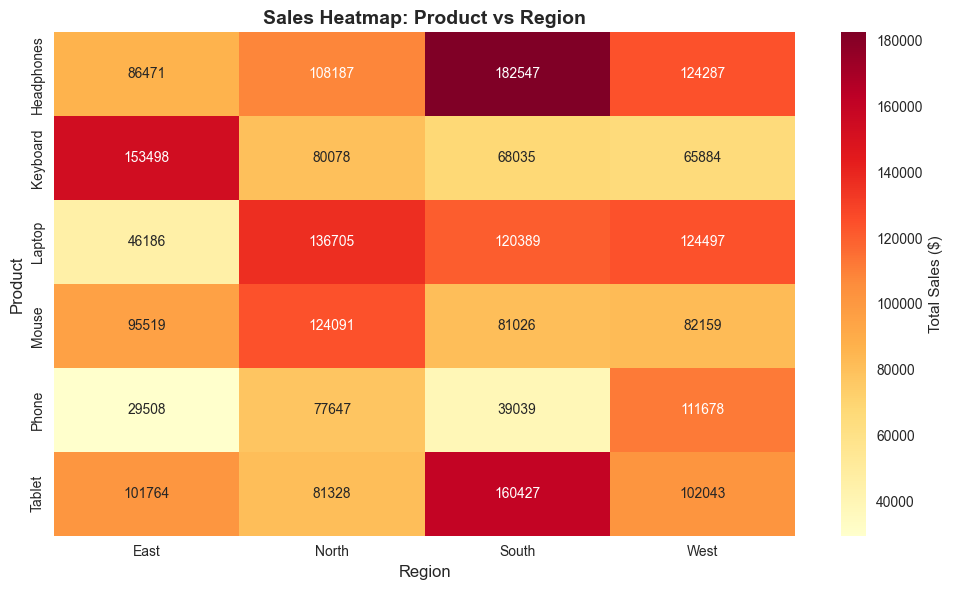

In [8]:
# Create heatmap for pivot1
plt.figure(figsize=(10, 6))
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Total Sales ($)'})
plt.title('Sales Heatmap: Product vs Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.show()

### Bar Chart of Total Sales by Product

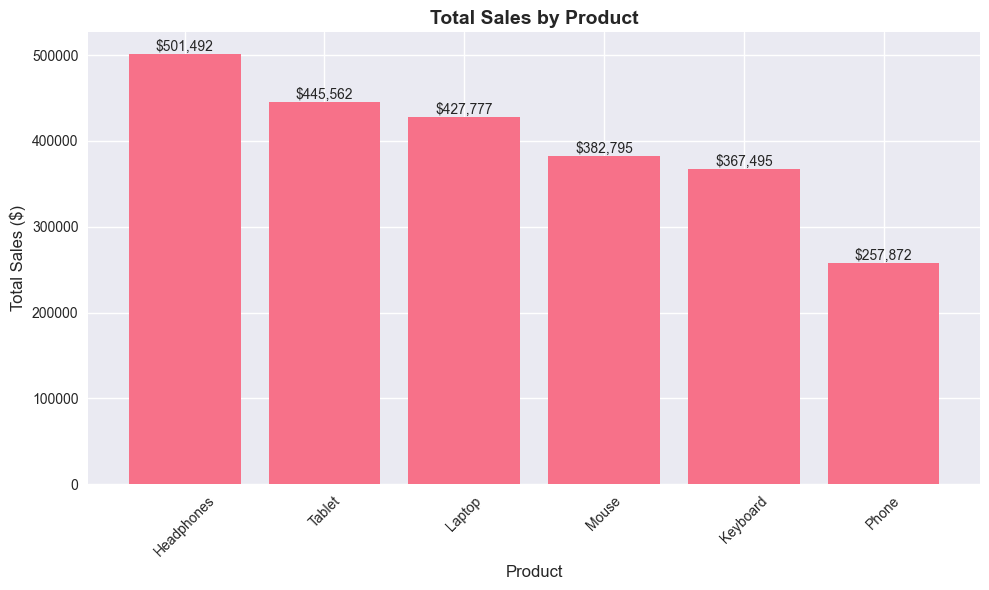

In [9]:
# Bar chart from pivot table
sales_by_product = pivot1.sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_product.index, sales_by_product.values)
plt.title('Total Sales by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Stacked Bar Chart by Region

<Figure size 1200x600 with 0 Axes>

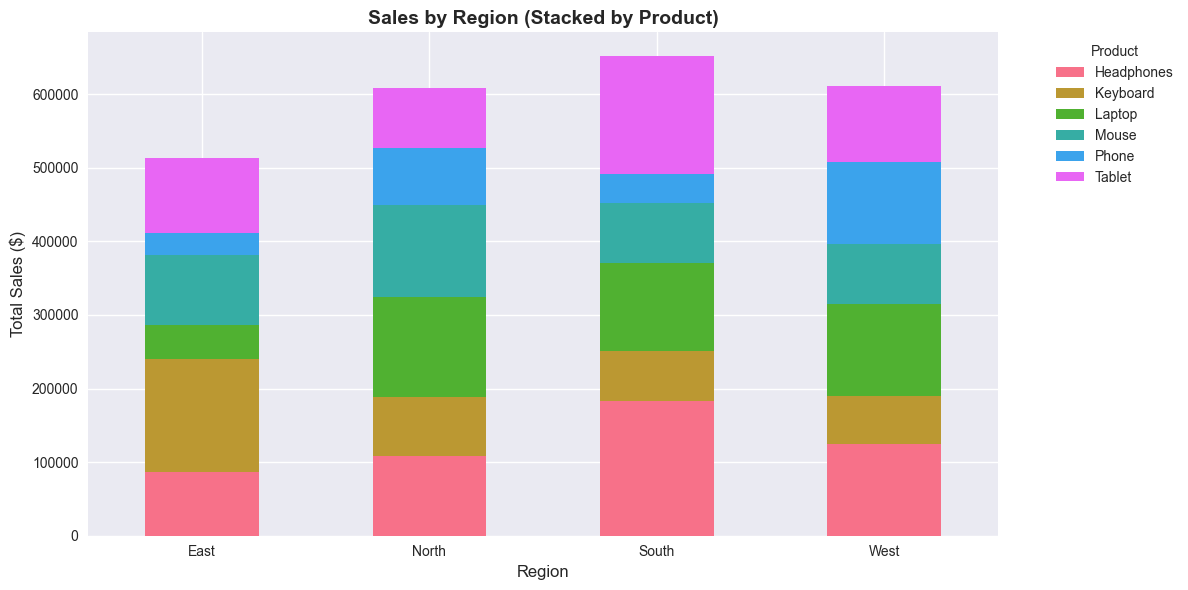

In [10]:
# Stacked bar chart
plt.figure(figsize=(12, 6))
pivot1.T.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Sales by Region (Stacked by Product)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Line Plot of Performance by Salesperson

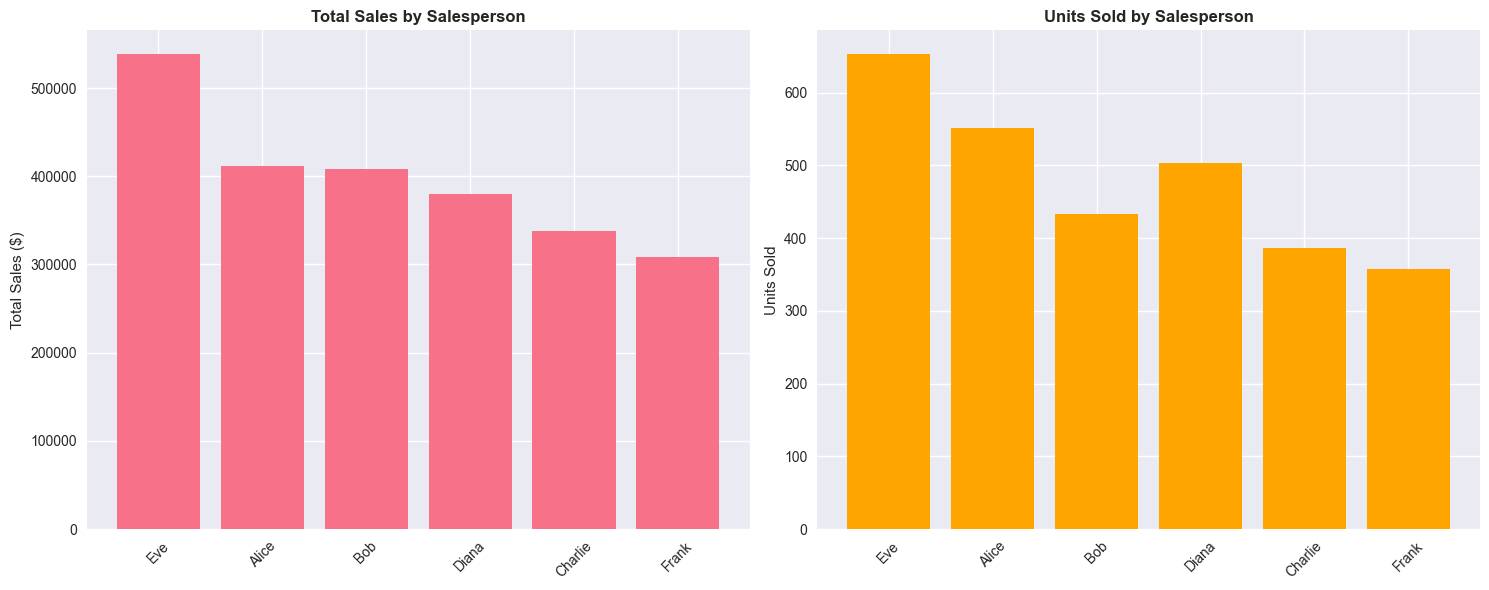

In [11]:
# Performance comparison
salesperson_performance = df.groupby('Salesperson').agg({
    'Total_Sales': 'sum',
    'Units_Sold': 'sum'
}).sort_values('Total_Sales', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Total Sales
ax1.bar(salesperson_performance.index, salesperson_performance['Total_Sales'])
ax1.set_title('Total Sales by Salesperson', fontweight='bold')
ax1.set_ylabel('Total Sales ($)')
ax1.tick_params(axis='x', rotation=45)

# Units Sold
ax2.bar(salesperson_performance.index, salesperson_performance['Units_Sold'], color='orange')
ax2.set_title('Units Sold by Salesperson', fontweight='bold')
ax2.set_ylabel('Units Sold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Advanced Visualization: Correlation Matrix

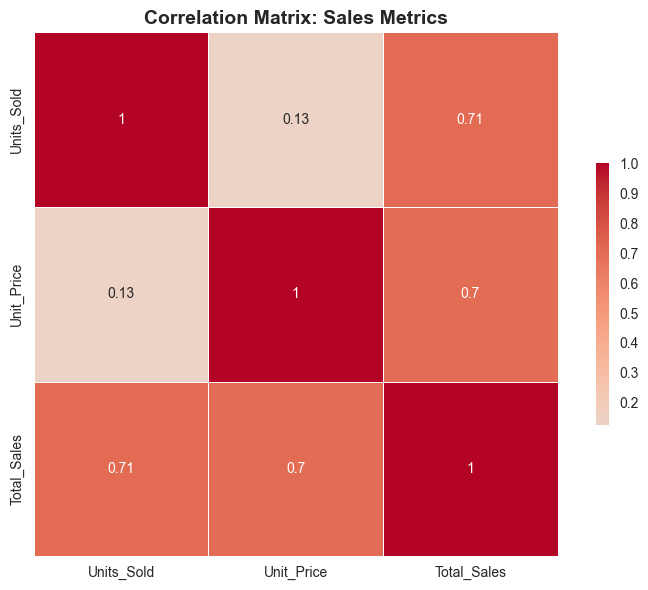

In [12]:
# Create correlation matrix from pivot data
corr_data = df[['Units_Sold', 'Unit_Price', 'Total_Sales']]
corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix: Sales Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Interactive Pivot Table Summary

In [13]:
# Summary statistics from pivot tables
print("=" * 50)
print("PIVOT TABLE ANALYSIS SUMMARY")
print("=" * 50)

print("\n1. Top Performing Products (by total sales):")
top_products = pivot1.sum(axis=1).sort_values(ascending=False)
for i, (product, sales) in enumerate(top_products.head(3).items(), 1):
    print(f"   {i}. {product}: ${sales:,.2f}")

print("\n2. Top Performing Regions (by total sales):")
top_regions = pivot1.sum(axis=0).sort_values(ascending=False)
for i, (region, sales) in enumerate(top_regions.head(3).items(), 1):
    print(f"   {i}. {region}: ${sales:,.2f}")

print("\n3. Most Productive Salesperson (by units sold):")
units_by_salesperson = df.groupby('Salesperson')['Units_Sold'].sum().sort_values(ascending=False)
for i, (person, units) in enumerate(units_by_salesperson.head(3).items(), 1):
    print(f"   {i}. {person}: {units} units")

print(f"\n4. Overall Performance Metrics:")
print(f"   • Total Revenue: ${df['Total_Sales'].sum():,.2f}")
print(f"   • Total Units Sold: {df['Units_Sold'].sum():,}")
print(f"   • Average Order Value: ${df['Total_Sales'].mean():.2f}")
print(f"   • Number of Transactions: {len(df):,}")

PIVOT TABLE ANALYSIS SUMMARY

1. Top Performing Products (by total sales):
   1. Headphones: $501,492.00
   2. Tablet: $445,562.00
   3. Laptop: $427,777.00

2. Top Performing Regions (by total sales):
   1. South: $651,463.00
   2. West: $610,548.00
   3. North: $608,036.00

3. Most Productive Salesperson (by units sold):
   1. Eve: 653 units
   2. Alice: 552 units
   3. Diana: 503 units

4. Overall Performance Metrics:
   • Total Revenue: $2,382,993.00
   • Total Units Sold: 2,885
   • Average Order Value: $7943.31
   • Number of Transactions: 300


## Conclusion

This notebook demonstrated:
- Creating comprehensive sample sales data
- Building multiple types of pivot tables with different aggregations
- Visualizing pivot table data using various chart types (heatmaps, bar charts, stacked charts)
- Extracting business insights from pivot table analysis

**Key Insights:**
- Pivot tables provide powerful data summarization capabilities
- Combining pivot tables with visualizations reveals patterns and trends
- Multi-dimensional analysis helps identify top performers and opportunities
- Different chart types highlight different aspects of the same data

**Next Steps:**
- Try filtering the data by date ranges
- Add more dimensions to the analysis
- Create interactive dashboards using plotly or bokeh
- Export pivot tables to Excel for further analysis

# Dynamic Pie Chart Visualization with Interactive Controls

This notebook creates an interactive pie chart visualization with dynamic controls that allow users to filter and customize the display in real-time.

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

## Step 1: Generate Sample Data

First, let's create a sample dataset with multiple categories and metrics for our dynamic pie chart.

In [ ]:
# Generate sample data for demonstration
np.random.seed(42)

# Create sample sales data by category and region
categories = ['Electronics', 'Clothing', 'Food', 'Books', 'Sports', 'Home & Garden']
regions = ['North', 'South', 'East', 'West']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

data = []
for month in months:
    for region in regions:
        for category in categories:
            sales = np.random.randint(1000, 10000)
            profit = sales * np.random.uniform(0.1, 0.3)
            data.append({
                'Month': month,
                'Region': region,
                'Category': category,
                'Sales': sales,
                'Profit': profit,
                'Units_Sold': np.random.randint(50, 500)
            })

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head()

## Step 2: Create Interactive Controls

We'll create various widgets to control the pie chart visualization dynamically.

In [ ]:
# Create interactive widgets for filtering and customization
month_dropdown = widgets.Dropdown(
    options=['All'] + list(df['Month'].unique()),
    value='All',
    description='Month:',
    style={'description_width': 'initial'}
)

region_dropdown = widgets.Dropdown(
    options=['All'] + list(df['Region'].unique()),
    value='All',
    description='Region:',
    style={'description_width': 'initial'}
)

metric_dropdown = widgets.Dropdown(
    options=['Sales', 'Profit', 'Units_Sold'],
    value='Sales',
    description='Metric:',
    style={'description_width': 'initial'}
)

# Color scheme selector
color_scheme = widgets.Dropdown(
    options=['plotly', 'viridis', 'plasma', 'inferno', 'magma', 'cividis'],
    value='plotly',
    description='Color Scheme:',
    style={'description_width': 'initial'}
)

# Show percentages toggle
show_percentages = widgets.Checkbox(
    value=True,
    description='Show Percentages',
    style={'description_width': 'initial'}
)

# Chart size slider
chart_size = widgets.IntSlider(
    value=600,
    min=400,
    max=1000,
    step=50,
    description='Chart Size:',
    style={'description_width': 'initial'}
)

print("Interactive controls created successfully!")

## Step 3: Define the Dynamic Pie Chart Function

This function will update the pie chart based on the selected filters and options.

In [ ]:
def create_dynamic_pie_chart(month_filter, region_filter, metric, color_scheme_val, show_pct, size):
    """Create a dynamic pie chart based on filter selections"""
    
    # Filter data based on selections
    filtered_df = df.copy()
    
    if month_filter != 'All':
        filtered_df = filtered_df[filtered_df['Month'] == month_filter]
    
    if region_filter != 'All':
        filtered_df = filtered_df[filtered_df['Region'] == region_filter]
    
    # Aggregate data by category
    agg_data = filtered_df.groupby('Category')[metric].sum().reset_index()
    agg_data = agg_data.sort_values(metric, ascending=False)
    
    # Create the pie chart
    fig = go.Figure()
    
    # Configure text display
    textinfo = 'label+percent' if show_pct else 'label'
    
    fig.add_trace(go.Pie(
        labels=agg_data['Category'],
        values=agg_data[metric],
        textinfo=textinfo,
        textposition='auto',
        hovertemplate='<b>%{label}</b><br>' +
                      f'{metric}: %{{value:,.0f}}<br>' +
                      'Percentage: %{percent}<br>' +
                      '<extra></extra>',
        marker=dict(
            colors=px.colors.qualitative.Set3 if color_scheme_val == 'plotly' else 
                   px.colors.sequential.__dict__[color_scheme_val.title()]
        )
    ))
    
    # Update layout
    title_parts = []
    if month_filter != 'All':
        title_parts.append(f"Month: {month_filter}")
    if region_filter != 'All':
        title_parts.append(f"Region: {region_filter}")
    
    title_suffix = f" ({', '.join(title_parts)})" if title_parts else " (All Data)"
    
    fig.update_layout(
        title={
            'text': f'{metric} Distribution by Category{title_suffix}',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 16}
        },
        width=size,
        height=size,
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="middle",
            y=0.5,
            xanchor="left",
            x=1.01
        ),
        margin=dict(l=20, r=120, t=70, b=20)
    )
    
    return fig

print("Dynamic pie chart function defined successfully!")

## Step 4: Create the Interactive Dashboard

Now we'll combine all the controls with the pie chart to create a fully interactive dashboard.

In [ ]:
def update_chart(*args):
    """Update the pie chart when any control changes"""
    with output:
        clear_output(wait=True)
        fig = create_dynamic_pie_chart(
            month_dropdown.value,
            region_dropdown.value,
            metric_dropdown.value,
            color_scheme.value,
            show_percentages.value,
            chart_size.value
        )
        fig.show()

# Create output widget for the chart
output = widgets.Output()

# Link all controls to the update function
month_dropdown.observe(update_chart, names='value')
region_dropdown.observe(update_chart, names='value')
metric_dropdown.observe(update_chart, names='value')
color_scheme.observe(update_chart, names='value')
show_percentages.observe(update_chart, names='value')
chart_size.observe(update_chart, names='value')

# Arrange controls in a grid layout
control_row1 = widgets.HBox([month_dropdown, region_dropdown, metric_dropdown])
control_row2 = widgets.HBox([color_scheme, show_percentages, chart_size])
controls = widgets.VBox([control_row1, control_row2])

# Create the complete dashboard
dashboard = widgets.VBox([controls, output])

# Initial chart display
update_chart()

print("Interactive dashboard ready! Use the controls below to customize your pie chart.")
display(dashboard)

## Step 5: Additional Features - Summary Statistics

Let's add a summary table that updates dynamically with the filters.

In [ ]:
def create_summary_table(month_filter, region_filter):
    """Create a summary statistics table based on current filters"""
    
    # Filter data
    filtered_df = df.copy()
    
    if month_filter != 'All':
        filtered_df = filtered_df[filtered_df['Month'] == month_filter]
    
    if region_filter != 'All':
        filtered_df = filtered_df[filtered_df['Region'] == region_filter]
    
    # Create summary by category
    summary = filtered_df.groupby('Category').agg({
        'Sales': ['sum', 'mean', 'count'],
        'Profit': ['sum', 'mean'],
        'Units_Sold': ['sum', 'mean']
    }).round(2)
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns]
    summary = summary.reset_index()
    
    return summary

# Create a button to show summary statistics
summary_button = widgets.Button(
    description='Show Summary Stats',
    button_style='info',
    icon='table'
)

summary_output = widgets.Output()

def show_summary(b):
    """Display summary statistics table"""
    with summary_output:
        clear_output(wait=True)
        summary_df = create_summary_table(
            month_dropdown.value,
            region_dropdown.value
        )
        print("📊 Summary Statistics for Current Selection:")
        print("=" * 50)
        display(summary_df)

summary_button.on_click(show_summary)

# Add summary section to dashboard
summary_section = widgets.VBox([
    widgets.HTML("<h3>📈 Summary Statistics</h3>"),
    summary_button,
    summary_output
])

print("Summary statistics feature added!")
display(summary_section)

## Step 6: Export Functionality

Add the ability to save the current chart configuration and data.

In [ ]:
import json
from datetime import datetime

# Export configuration button
export_button = widgets.Button(
    description='Export Current View',
    button_style='success',
    icon='download'
)

export_output = widgets.Output()

def export_current_view(b):
    """Export current chart configuration and filtered data"""
    with export_output:
        clear_output(wait=True)
        
        # Get current configuration
        config = {
            'timestamp': datetime.now().isoformat(),
            'filters': {
                'month': month_dropdown.value,
                'region': region_dropdown.value,
                'metric': metric_dropdown.value,
                'color_scheme': color_scheme.value,
                'show_percentages': show_percentages.value,
                'chart_size': chart_size.value
            }
        }
        
        # Filter and aggregate current data
        filtered_df = df.copy()
        if config['filters']['month'] != 'All':
            filtered_df = filtered_df[filtered_df['Month'] == config['filters']['month']]
        if config['filters']['region'] != 'All':
            filtered_df = filtered_df[filtered_df['Region'] == config['filters']['region']]
        
        agg_data = filtered_df.groupby('Category')[config['filters']['metric']].sum().reset_index()
        
        print("✅ Current view exported successfully!")
        print(f"📅 Timestamp: {config['timestamp']}")
        print(f"🔧 Configuration: {config['filters']}")
        print("\n📊 Current Data:")
        display(agg_data.sort_values(config['filters']['metric'], ascending=False))
        
        # Save configuration as JSON (in a real scenario, you might save to file)
        config_json = json.dumps(config, indent=2)
        print(f"\n💾 Configuration JSON:\n{config_json}")

export_button.on_click(export_current_view)

# Create export section
export_section = widgets.VBox([
    widgets.HTML("<h3>💾 Export Options</h3>"),
    export_button,
    export_output
])

print("Export functionality added!")
display(export_section)

## Conclusion

🎉 **Dynamic Pie Chart Dashboard Complete!**

This interactive dashboard provides:

### Features:
- **Real-time filtering** by month and region
- **Multiple metrics** (Sales, Profit, Units Sold)
- **Customizable appearance** (colors, size, percentage display)
- **Summary statistics** with detailed breakdowns
- **Export functionality** for saving current views

### Usage Tips:
1. Use the dropdown menus to filter your data
2. Switch between different metrics to analyze various aspects
3. Customize the visual appearance with color schemes and size
4. Generate summary statistics for detailed analysis
5. Export your current view for reporting or sharing

### Next Steps:
- Connect to real data sources (CSV, databases, APIs)
- Add more chart types (bar, line, scatter)
- Implement data refresh capabilities
- Add more advanced filtering options
- Create dashboard templates for different use cases

In [ ]:
# Final summary of the dashboard capabilities
print("🚀 Dynamic Pie Chart Dashboard Summary:")
print("=" * 50)
print(f"📊 Total data points: {len(df)}")
print(f"🏷️  Categories: {len(df['Category'].unique())}")
print(f"📍 Regions: {len(df['Region'].unique())}")
print(f"📅 Months: {len(df['Month'].unique())}")
print(f"📈 Metrics available: {len(['Sales', 'Profit', 'Units_Sold'])}")
print("\n✨ All interactive controls are now active above!")
print("   Modify any setting to see real-time updates.")

# Display sample of the data structure
print("\n📋 Sample Data Structure:")
df.head()